In [10]:
# Cell 1 — set paths
screenshot_path = r"C:\Users\70133\PixelWeb\pixelweb_1k\annotated\pixelweb_1k_annotated\0-screenshot.png"
bbox_json_path  = r"C:\Users\70133\PixelWeb\pixelweb_1k\annotated\pixelweb_1k_annotated\0-bbox.json"
class_json_path = r"C:\Users\70133\PixelWeb\pixelweb_1k\annotated\pixelweb_1k_annotated\0-class.json"
contour_json_path = r"C:\Users\70133\PixelWeb\pixelweb_1k\annotated\pixelweb_1k_annotated\0-contour.json"
mask_json_path = r"C:\Users\70133\PixelWeb\pixelweb_1k\annotated\pixelweb_1k_annotated\0-mask.json"

# Optional settings
max_boxes  = None   # e.g. 200
line_width = 2
fig_width  = 12
max_elements = None   # e.g. 200
show_labels  = True


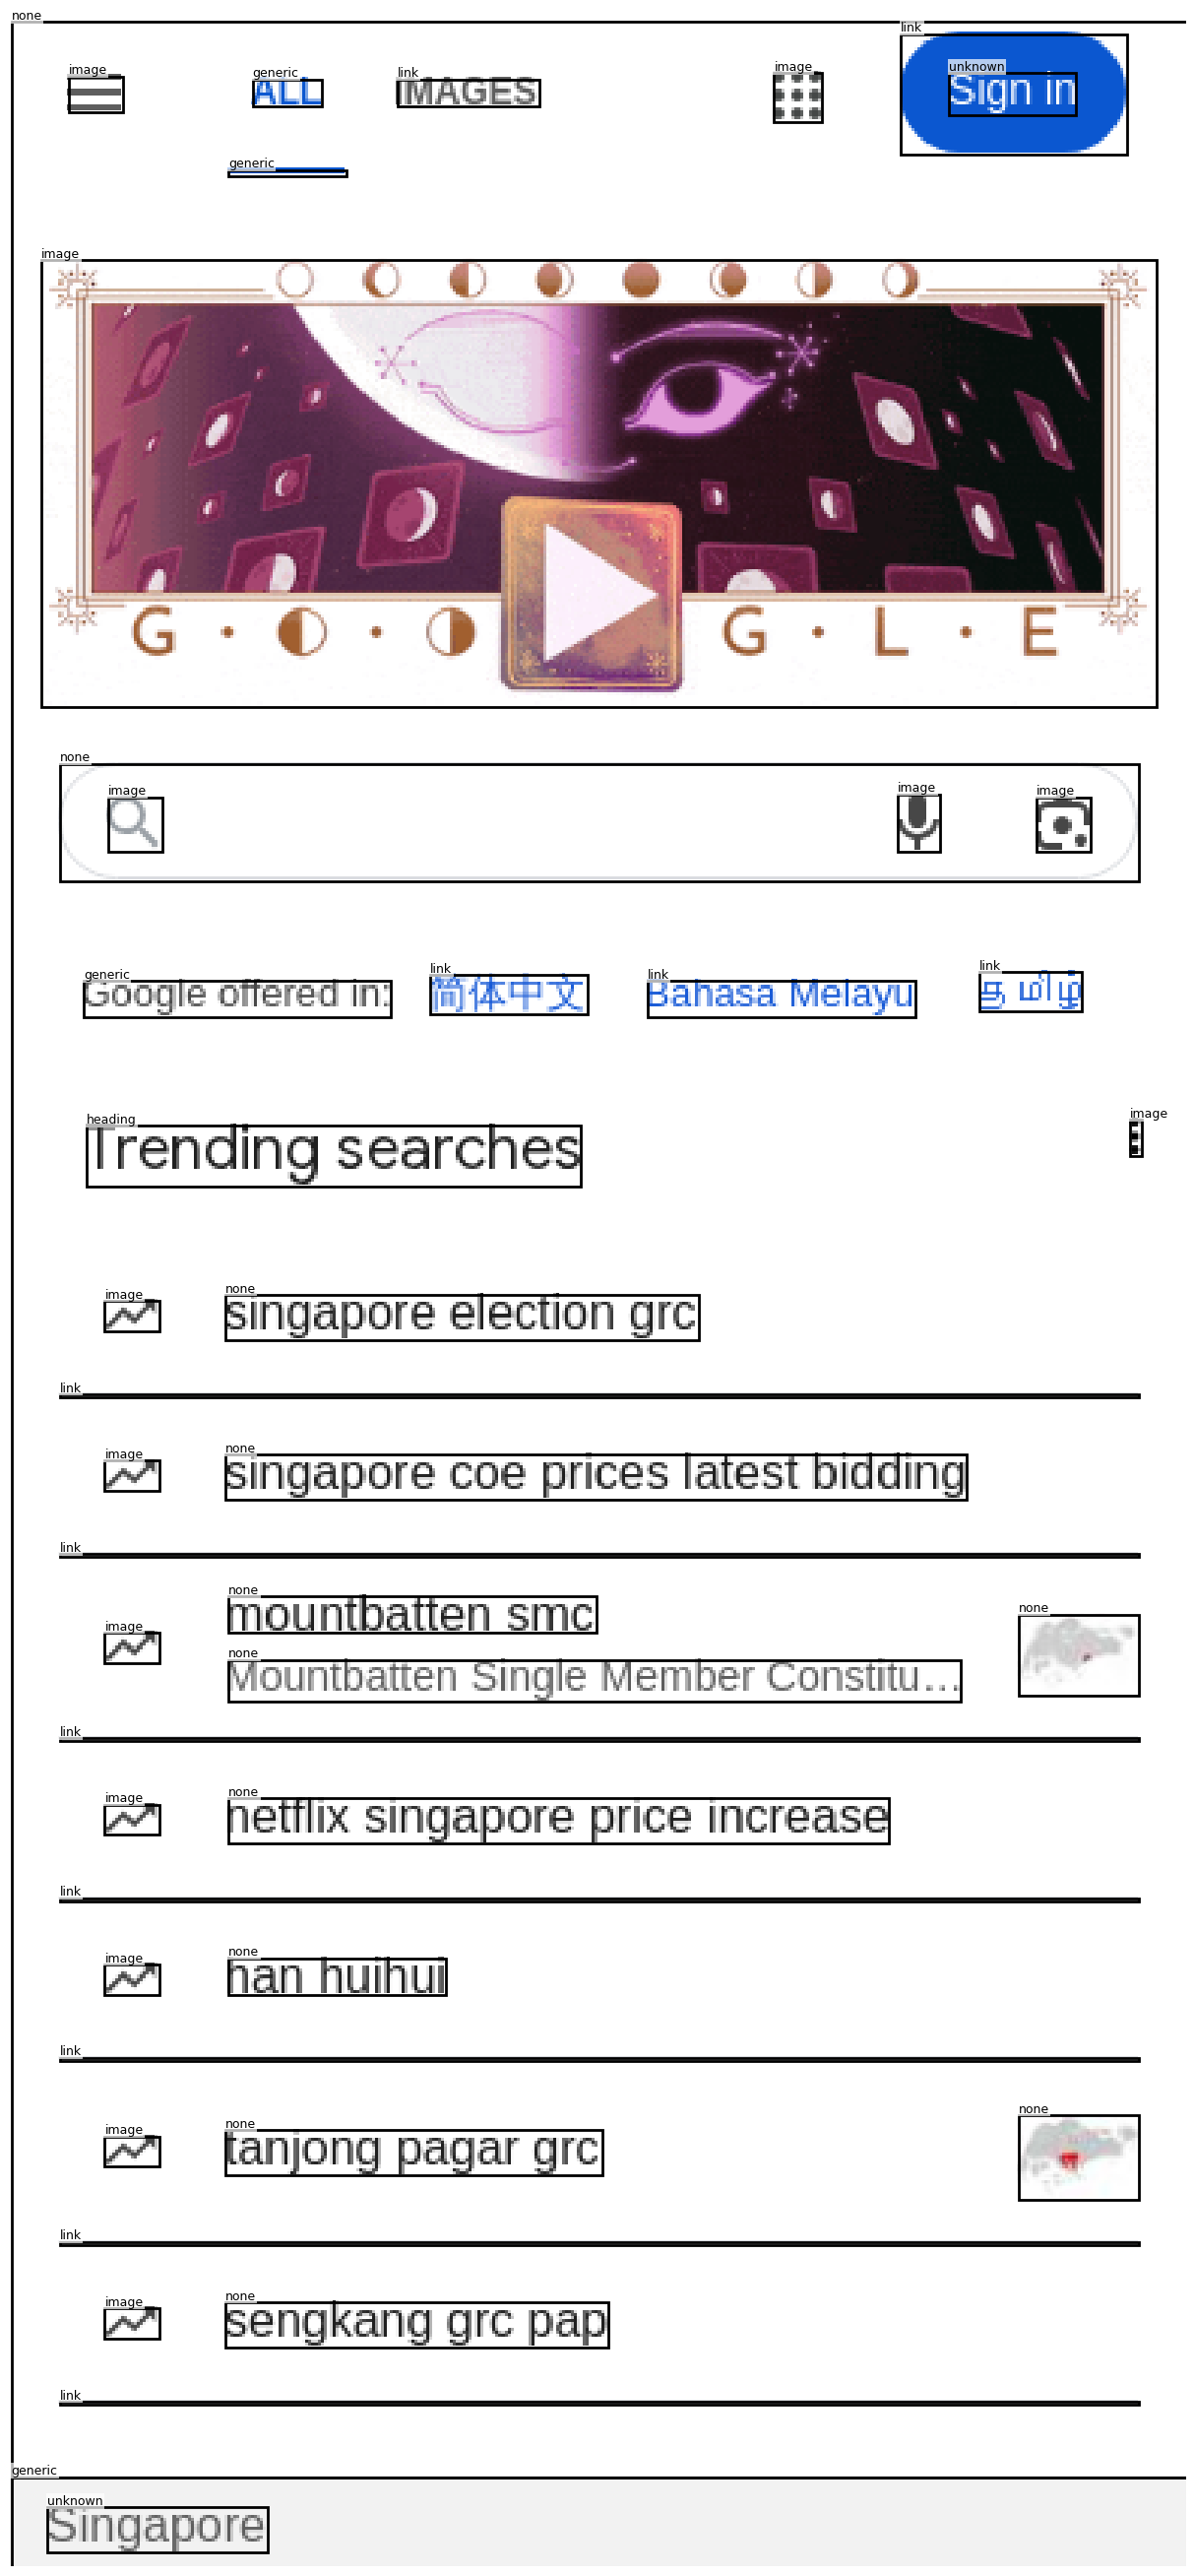

In [2]:
# Cell 2 — draw bboxes with class labels

import json
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches


def load_json(path):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"File not found: {path}")
    return json.loads(path.read_text(encoding="utf-8"))


def load_bboxes(bbox_path):
    data = load_json(bbox_path)
    if not isinstance(data, list):
        raise ValueError("BBox JSON must be a list.")
    bboxes = []
    for i, box in enumerate(data):
        if not (isinstance(box, list) and len(box) == 4):
            raise ValueError(f"Invalid bbox at index {i}: {box}")
        left, top, w, h = map(float, box)
        bboxes.append((left, top, w, h))
    return bboxes


def load_classes(class_path):
    data = load_json(class_path)
    if not (isinstance(data, list) and all(isinstance(x, str) for x in data)):
        raise ValueError("Class JSON must be a list of strings.")
    return data


def draw_bboxes_on_image(image_path, bboxes, classes=None, max_boxes=None, line_width=2, fig_width=12):
    img = Image.open(image_path).convert("RGBA")
    W, H = img.size

    # Keep aspect ratio (avoid 'squeezed' look)
    fig_height = fig_width * (H / W)
    fig, ax = plt.subplots(figsize=(fig_width, fig_height))
    ax.imshow(img, interpolation="nearest")
    ax.set_aspect("equal")
    ax.axis("off")

    n = len(bboxes) if max_boxes is None else min(len(bboxes), int(max_boxes))

    # If classes provided, ensure we don't index out of range
    if classes is not None:
        n = min(n, len(classes))

    for idx in range(n):
        left, top, w, h = bboxes[idx]
        if w <= 0 or h <= 0:
            continue

        ax.add_patch(patches.Rectangle((left, top), w, h, fill=False, linewidth=line_width))

        label = None
        if classes is not None:
            label = classes[idx]
        else:
            label = str(idx)

        ax.text(
            left, top, label,
            fontsize=9, va="bottom", ha="left",
            bbox=dict(facecolor="white", alpha=0.7, edgecolor="none", pad=1),
        )

    plt.tight_layout(pad=0)
    plt.show()


# Run
bboxes = load_bboxes(bbox_json_path)
classes = load_classes(class_json_path)

if len(bboxes) != len(classes):
    print(f"Warning: bboxes={len(bboxes)} but classes={len(classes)} (will draw min of both).")

draw_bboxes_on_image(
    screenshot_path,
    bboxes,
    classes=classes,
    max_boxes=max_boxes,
    line_width=line_width,
    fig_width=fig_width
)


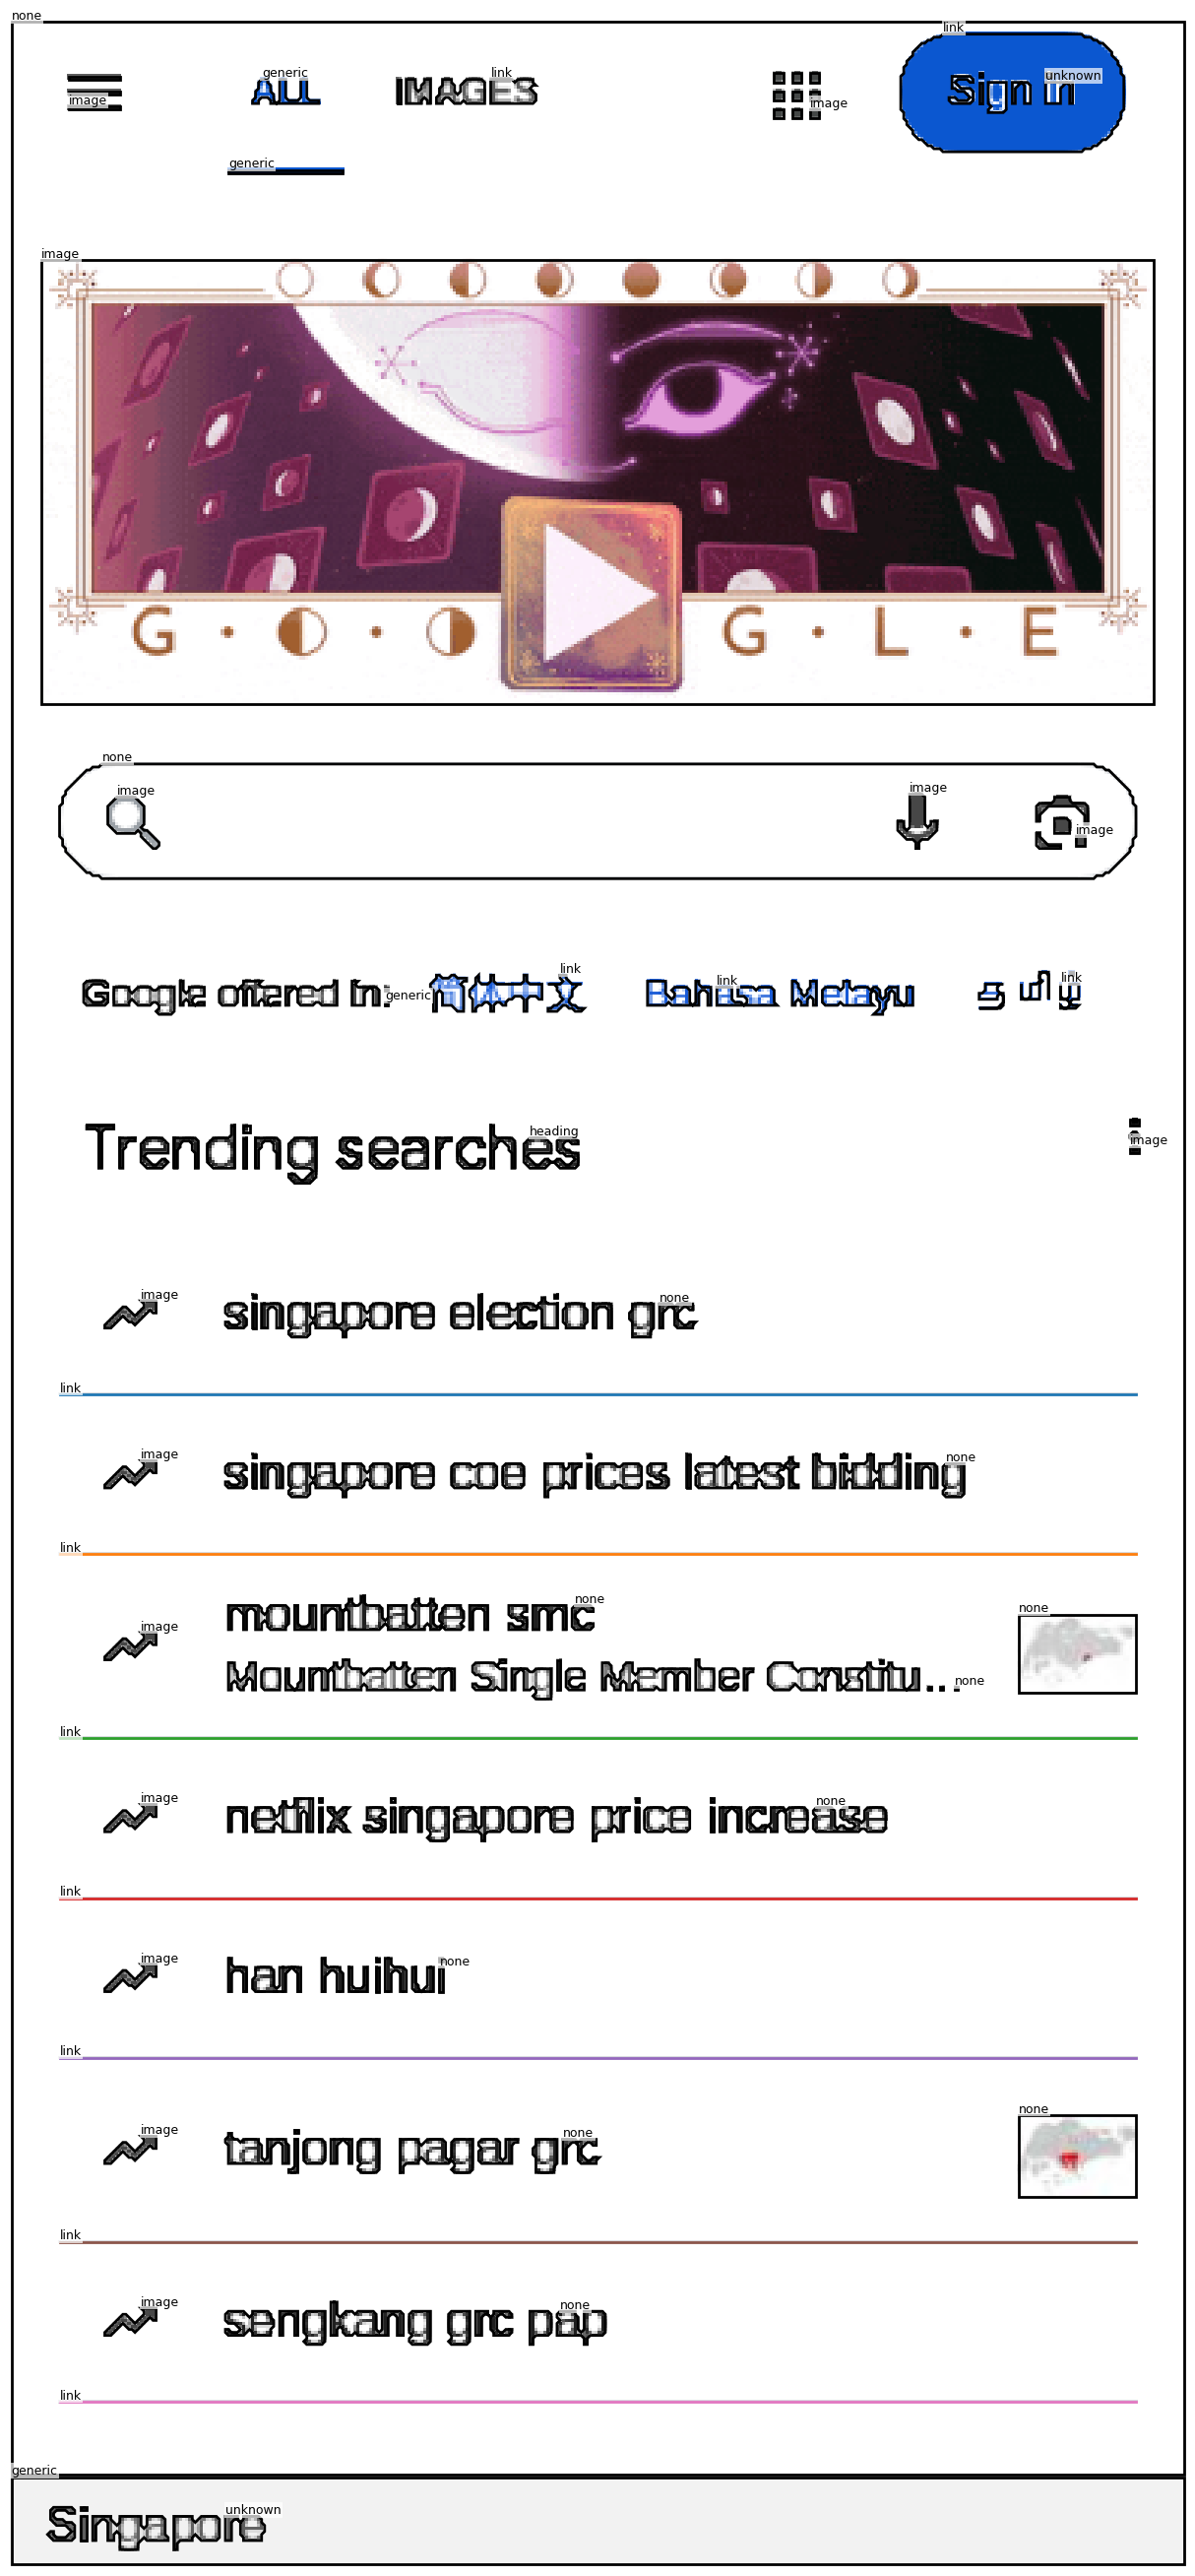

In [ ]:
# Cell 3 — draw contours overlay

import json
from pathlib import Path

from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches


def load_json(path):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"File not found: {path}")
    return json.loads(path.read_text(encoding="utf-8"))


def load_classes(class_path):
    if class_path is None:
        return None
    data = load_json(class_path)
    if not (isinstance(data, list) and all(isinstance(x, str) for x in data)):
        raise ValueError("Class JSON must be a list of strings.")
    return data


def load_contours(contour_path):
    """
    Expected format:
    [
      [ [x1,y1,x2,y2,...], [ ... ] ],   # element 0 (can have multiple contours)
      [ [x1,y1,...] ],                  # element 1
      ...
    ]
    """
    data = load_json(contour_path)
    if not isinstance(data, list):
        raise ValueError("Contour JSON must be a list (per-element).")

    parsed = []
    for elem_id, elem_contours in enumerate(data):
        if not isinstance(elem_contours, list):
            raise ValueError(f"Contours for element {elem_id} must be a list.")

        elem_polys = []
        for c_idx, coords in enumerate(elem_contours):
            if not (isinstance(coords, list) and len(coords) >= 4):
                continue  # skip invalid/empty contours

            if len(coords) % 2 != 0:
                raise ValueError(f"Contour coords length must be even. element={elem_id}, contour={c_idx}")

            # Convert flat [x1,y1,x2,y2,...] to [(x1,y1), (x2,y2), ...]
            pts = []
            for i in range(0, len(coords), 2):
                x = float(coords[i])
                y = float(coords[i + 1])
                pts.append((x, y))

            elem_polys.append(pts)

        parsed.append(elem_polys)

    return parsed


def draw_contours_on_image(image_path, contours, classes=None, show_labels=True,
                           max_elements=None, line_width=2, fig_width=12):
    img = Image.open(image_path).convert("RGBA")
    W, H = img.size

    # Keep aspect ratio (avoid "squeezed" look)
    fig_height = fig_width * (H / W)
    fig, ax = plt.subplots(figsize=(fig_width, fig_height))
    ax.imshow(img, interpolation="nearest")
    ax.set_aspect("equal")
    ax.axis("off")

    n = len(contours) if max_elements is None else min(len(contours), int(max_elements))
    if classes is not None:
        n = min(n, len(classes))

    for elem_id in range(n):
        poly_list = contours[elem_id]
        if not poly_list:
            continue

        # Draw each contour polygon for this element
        for pts in poly_list:
            if len(pts) < 2:
                continue

            # Use Polygon when we have >=3 points, otherwise just a polyline
            if len(pts) >= 3:
                patch = patches.Polygon(pts, closed=True, fill=False, linewidth=line_width)
                ax.add_patch(patch)
            else:
                xs = [p[0] for p in pts]
                ys = [p[1] for p in pts]
                ax.plot(xs, ys, linewidth=line_width)

        # Label near the first point of the first contour
        if show_labels:
            label = classes[elem_id] if classes is not None else str(elem_id)
            x0, y0 = poly_list[0][0]
            ax.text(
                x0, y0, label,
                fontsize=9, va="bottom", ha="left",
                bbox=dict(facecolor="white", alpha=0.7, edgecolor="none", pad=1),
            )

    plt.tight_layout(pad=0)
    plt.show()


# Run
classes  = load_classes(class_json_path)
contours = load_contours(contour_json_path)

if classes is not None and len(classes) != len(contours):
    print(f"Warning: classes={len(classes)} but contours={len(contours)} (will draw min of both).")

draw_contours_on_image(
    screenshot_path,
    contours,
    classes=classes,
    show_labels=show_labels,
    max_elements=max_elements,
    line_width=line_width,
    fig_width=fig_width
)


Mask size (H, W): (844, 390)
Unique layers (element_ids): 45
First 30 ids: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30]


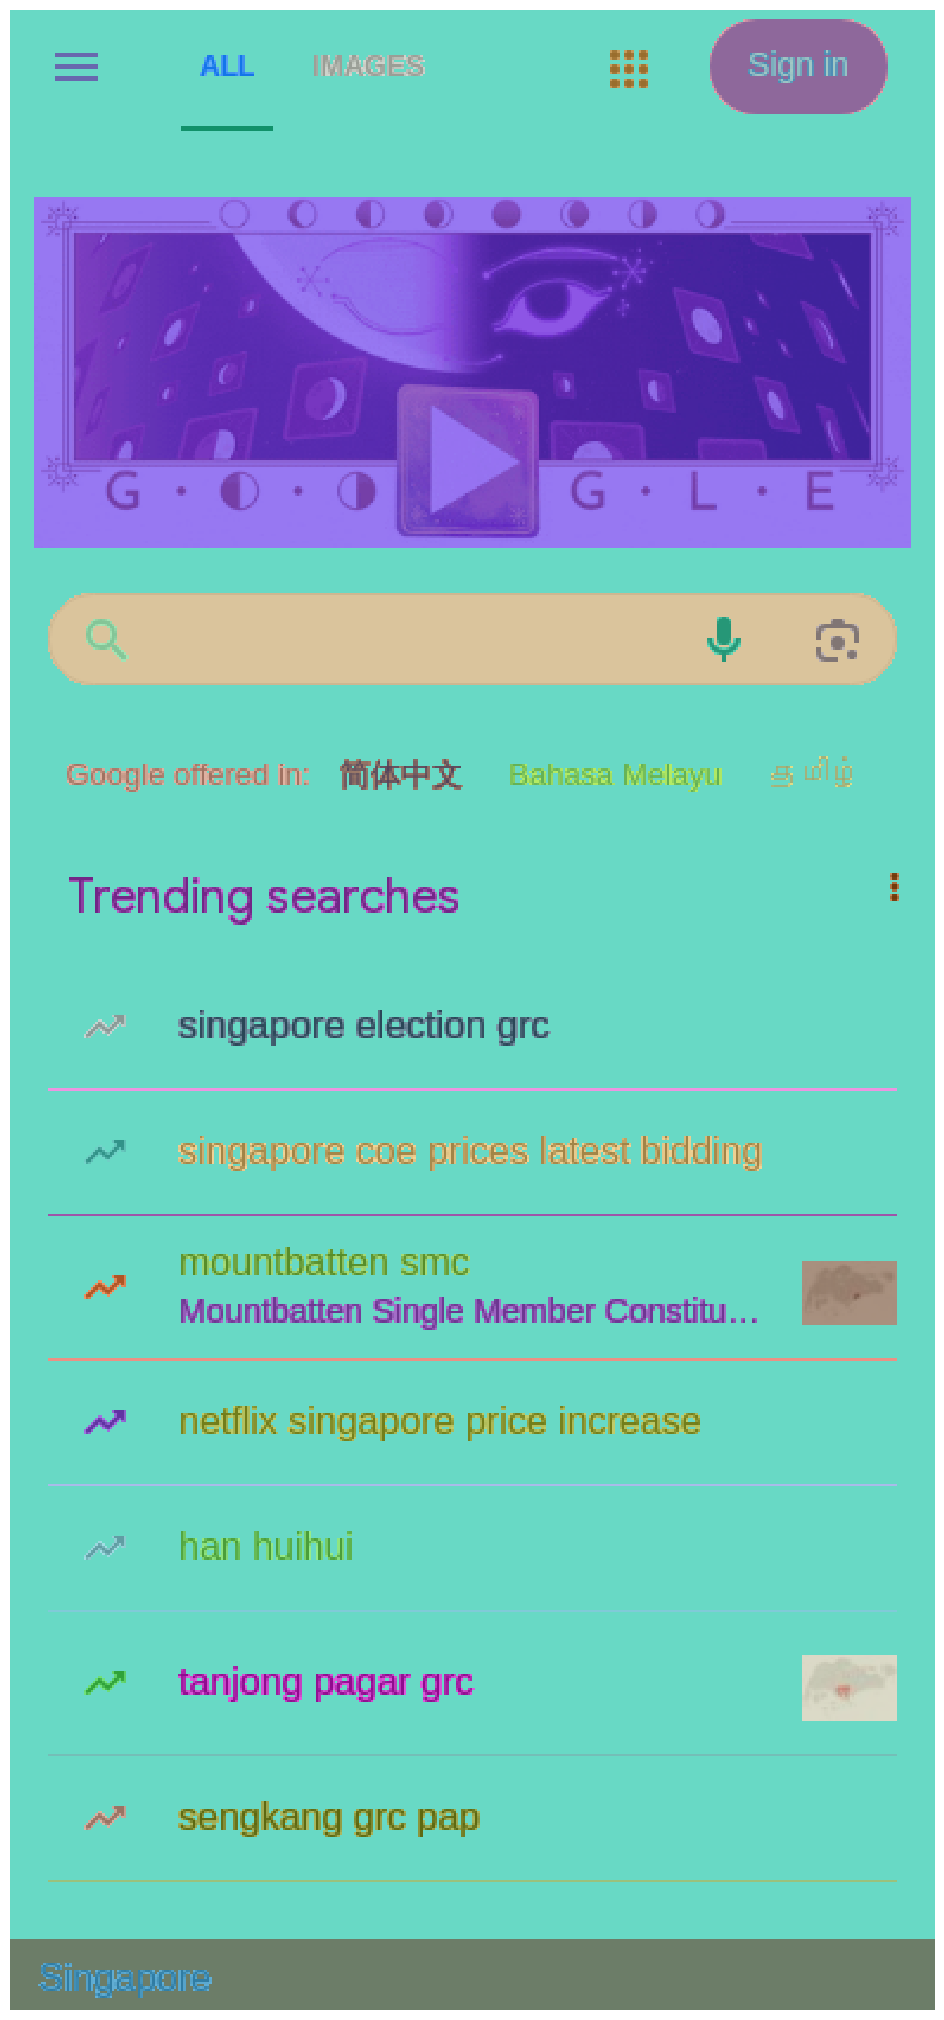

In [12]:
# Cell — visualize {id}-mask.json (pixel-wise element_id) with a unique color per layer/element

import json
import numpy as np
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

# If you want overlay on the screenshot, keep screenshot_path (you already have it). Otherwise set overlay_on_screenshot=False.
# screenshot_path = r"C:\path\to\0-screenshot.png"

# Options
overlay_on_screenshot = True      # True = show on top of screenshot, False = show mask alone
seed = 42                         # deterministic colors
overlay_alpha = 0.65              # transparency of colored layers (0..1)
background_ids = {-1}             # ids to treat as "background" (transparent). If needed add 0: {-1, 0}
max_fig_height = 20               # limit figure height in notebook (doesn't distort, only scales)

# Load mask (H x W) where each pixel is element_id
mask = np.array(json.loads(Path(mask_json_path).read_text(encoding="utf-8")), dtype=np.int32)
H, W = mask.shape

unique_ids, inv = np.unique(mask, return_inverse=True)  # inv maps each pixel -> index in unique_ids
K = len(unique_ids)

print("Mask size (H, W):", (H, W))
print("Unique layers (element_ids):", K)
print("First 30 ids:", unique_ids[:30])

# Generate random color per unique id
rng = np.random.default_rng(seed)
colors = rng.random((K, 3), dtype=np.float32)           # RGB in [0,1]
alphas = np.full((K, 1), overlay_alpha, dtype=np.float32)

# Make background ids fully transparent (if present)
bg_mask = np.isin(unique_ids, list(background_ids))
colors[bg_mask] = 0.0
alphas[bg_mask] = 0.0

# Build RGBA image using the inverse index map (fast, no loops over ids)
rgb = colors[inv].reshape(H, W, 3)
a   = alphas[inv].reshape(H, W, 1)
rgba = np.concatenate([rgb, a], axis=-1)

# Plot
fig_width = 12
fig_height = min(max_fig_height, fig_width * (H / W))

fig, ax = plt.subplots(figsize=(fig_width, fig_height))

if overlay_on_screenshot:
    img = Image.open(screenshot_path).convert("RGBA")
    ax.imshow(img, interpolation="nearest")
    ax.imshow(rgba, interpolation="nearest")  # uses alpha channel per-pixel
else:
    ax.imshow(rgba, interpolation="nearest")

ax.set_aspect("equal")
ax.axis("off")
plt.tight_layout(pad=0)
plt.show()
